In [2]:
!pip install hmmlearn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
cd SAF_final_project

/Users/gaohan/saf_final_project


In [10]:
import return_regime_utils as rru

raw = rru.load_return_data("01_Data_Preprocessing_EDA/data/spy_returns_eda_output.csv")
feats = rru.build_features(raw, return_col="log_return")

result = rru.rolling_regime_forecast(
    feature_df=feats,
    raw_df=raw,
    return_col="log_return",
    train_end="2023-12-31",
    test_start="2024-01-01",
    n_states=3,
    expanding=True,
    min_train_size=252,
)

print(result.summary)
print(result.metrics)
print(result.predictions.head())

Model is not converging.  Current: 11806.964293303032 is not greater than 21491.368078529373. Delta is -9684.403785226341
Model is not converging.  Current: 11815.688814247367 is not greater than 21500.10484031625. Delta is -9684.416026068882
Model is not converging.  Current: 11842.174013502108 is not greater than 14145.656294572507. Delta is -2303.482281070399
Model is not converging.  Current: 11852.74868937136 is not greater than 14232.073119833125. Delta is -2379.3244304617656
Model is not converging.  Current: 11846.994260069414 is not greater than 22019.83853783151. Delta is -10172.844277762097
Model is not converging.  Current: 21823.93002517025 is not greater than 22047.366398207243. Delta is -223.43637303699143
Model is not converging.  Current: 21832.63530023617 is not greater than 22056.10452055659. Delta is -223.4692203204213
Model is not converging.  Current: 11880.909602986801 is not greater than 20151.19098675782. Delta is -8270.28138377102
Model is not converging.  Cur

   state  count  avg_return  volatility  annualised_return_approx  \
1      1     54   -0.004701    0.042661                 -1.184568   
0      0    530    0.000252    0.013168                  0.063565   
2      2    653    0.001176    0.006638                  0.296238   

   annualised_vol_approx  
1               0.677215  
0               0.209043  
2               0.105383  
            model       mae       mse  directional_accuracy
1  hist_mean_pred  0.005807  0.000063              0.589641
0     regime_pred  0.005822  0.000063              0.589641
2        ar1_pred  0.005919  0.000065              0.525896
               regime_pred  hist_mean_pred  ar1_pred  actual_return
forecast_date                                                      
2024-01-03        0.001125        0.000518  0.001525      -0.008200
2024-01-04        0.000627        0.000511  0.001939      -0.003226
2024-01-05        0.000614        0.000508  0.001119       0.001369
2024-01-08        0.000560        0

In [13]:
results = []

for k in [2, 3, 4]:
    result = rru.rolling_regime_forecast(
        feature_df=feats,
        raw_df=raw,
        return_col="log_return",
        train_end="2023-12-31",
        test_start="2024-01-01",
        n_states=k,
        expanding=True,
        min_train_size=252,
    )
    
    metrics_row = result.metrics.copy()
    metrics_row["n_states"] = k
    results.append(metrics_row)



Model is not converging.  Current: 13327.327556038244 is not greater than 17909.558703652074. Delta is -4582.231147613829
Model is not converging.  Current: 13377.620648073795 is not greater than 22443.334816391438. Delta is -9065.714168317643
Model is not converging.  Current: 13438.843470205715 is not greater than 25587.223457449094. Delta is -12148.37998724338
Model is not converging.  Current: 13395.699679060604 is not greater than 22183.555353405092. Delta is -8787.855674344488
Model is not converging.  Current: 13361.245470518692 is not greater than 17847.889242364454. Delta is -4486.643771845762
Model is not converging.  Current: 13368.467128032236 is not greater than 17057.283122937988. Delta is -3688.8159949057517
Model is not converging.  Current: 13426.905329924446 is not greater than 22310.73883138949. Delta is -8883.833501465046
Model is not converging.  Current: 13393.825670588056 is not greater than 18161.203760471424. Delta is -4767.378089883368
Model is not converging.

In [14]:
import pandas as pd
search_df = pd.concat(results, ignore_index=True)
print(search_df)

            model       mae       mse  directional_accuracy  n_states
0  hist_mean_pred  0.005807  0.000063              0.589641         2
1     regime_pred  0.005822  0.000063              0.577689         2
2        ar1_pred  0.005919  0.000065              0.525896         2
3  hist_mean_pred  0.005807  0.000063              0.589641         3
4     regime_pred  0.005822  0.000063              0.589641         3
5        ar1_pred  0.005919  0.000065              0.525896         3
6  hist_mean_pred  0.005807  0.000063              0.589641         4
7     regime_pred  0.005878  0.000064              0.581673         4
8        ar1_pred  0.005919  0.000065              0.525896         4


In [36]:
train_feat = feats.loc[: "2023-12-31"].copy()
aligned_returns = raw["log_return"].reindex(train_feat.index)

model_2 = rru.fit_hmm(
    train_feat.values,
    n_states=2,
    covariance_type="diag",
    n_iter=200,
    random_state=42,)

summary_2 = rru.summarise_regimes(
    model=model_2,
    X=train_feat.values,
    index=train_feat.index,
    return_series=aligned_returns,
)

forecast_result_2 = rru.rolling_regime_forecast(
    feature_df=feats,
    raw_df=raw,
    return_col="log_return",
    train_end="2023-12-31",
    test_start="2024-01-01",
    n_states=2,
    expanding=True,
    min_train_size=252,
)


Model is not converging.  Current: 13327.327556038244 is not greater than 17909.558703652074. Delta is -4582.231147613829
Model is not converging.  Current: 13377.620648073795 is not greater than 22443.334816391438. Delta is -9065.714168317643
Model is not converging.  Current: 13438.843470205715 is not greater than 25587.223457449094. Delta is -12148.37998724338
Model is not converging.  Current: 13395.699679060604 is not greater than 22183.555353405092. Delta is -8787.855674344488
Model is not converging.  Current: 13361.245470518692 is not greater than 17847.889242364454. Delta is -4486.643771845762
Model is not converging.  Current: 13368.467128032236 is not greater than 17057.283122937988. Delta is -3688.8159949057517
Model is not converging.  Current: 13426.905329924446 is not greater than 22310.73883138949. Delta is -8883.833501465046
Model is not converging.  Current: 13393.825670588056 is not greater than 18161.203760471424. Delta is -4767.378089883368
Model is not converging.

In [37]:
import importlib
import return_regime_utils as rru

importlib.reload(rru)

print(hasattr(rru, "regime_persistence_from_transition_matrix"))
print(hasattr(rru, "realised_regime_persistence"))
print(hasattr(rru, "build_market_stress_indicators"))
print(hasattr(rru, "evaluate_regime_alignment"))
print(hasattr(rru, "evaluate_regime_interpretability"))

True
True
True
True
True


In [38]:
persistence_tm_2 = rru.regime_persistence_from_transition_matrix(model_2)
print(persistence_tm_2)

persistence_realized_2 = rru.realised_regime_persistence(model_2, train_feat.values, train_feat.index)
print(persistence_realized_2)

stress_df = rru.build_market_stress_indicators(raw)
alignment_2 = rru.evaluate_regime_alignment(model_2, train_feat.values, train_feat.index, stress_df)
print(alignment_2)

interpretability_2 = rru.evaluate_regime_interpretability(summary_2)
print(interpretability_2)

   state  self_transition_prob  expected_duration_periods
0      0              0.986304                  73.016438
1      1              0.953017                  21.284407
   state  n_runs  avg_run_length  median_run_length  max_run_length
0      0      13       74.000000               17.0             317
1      1      12       22.916667                9.5              66
   state  count  pct_high_vol_days  pct_negative_return_days  \
0      0    962           0.000000                  0.431393   
1      1    275           0.541818                  0.527273   

   pct_drawdown_stress_days  
0                  0.103950  
1                  0.709091  
   n_states  return_spread_across_states  vol_spread_across_states  \
0         2                     0.002137                  0.015592   

   weighted_avg_abs_return  weighted_avg_volatility  return_spread_ratio  \
0                  0.00103                 0.011597             2.075596   

   vol_spread_ratio  different_return_vs_vol_

In [44]:
display(forecast_result_2.metrics)

,model,rmse,mae,mse,directional_accuracy,r2_oos_vs_zero,ic
0,regime_pred,0.00795,0.005822,0.000063,0.577689,0.004713,-0.002139


# regime characterization

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

In [46]:
def fit_hmm_for_regime_characterization(
    df,
    feature_cols,
    return_col="log_return",
    n_states=2,
    covariance_type="diag",
    n_iter=200,
    random_state=42,
    standardize=True,
):
    """
    Fit a Gaussian HMM using the selected feature columns and return
    a dataframe with inferred hidden states and state probabilities.


    Returns
    -------
    result_df : pd.DataFrame
        Original selected columns plus inferred state labels and state probabilities.
    model : GaussianHMM
        Fitted HMM model.
    scaler : StandardScaler or None
        Fitted scaler if standardization is used, otherwise None.
    """

    # Keep only the columns needed for modeling and remove missing values
    use_cols = feature_cols + [return_col]
    result_df = df[use_cols].dropna().copy()

    # Extract the feature matrix used by the HMM
    X = result_df[feature_cols].values

    # Standardize features if requested so that different feature scales
    # do not dominate the HMM estimation
    scaler = None
    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    # Fit the Gaussian HMM
    model = GaussianHMM(
        n_components=n_states,
        covariance_type=covariance_type,
        n_iter=n_iter,
        random_state=random_state,
    )
    model.fit(X)

    # Assign the most likely hidden state to each observation
    hidden_states = model.predict(X)
    result_df["state"] = hidden_states

    # Compute posterior probabilities for each state at each time point
    state_probs = model.predict_proba(X)

    for i in range(n_states):
        result_df[f"prob_state_{i}"] = state_probs[:, i]

    return result_df, model, scaler

In [47]:
def summarize_regimes(result_df, return_col="log_return", annualization=252):
    """
    Summarize each inferred regime using return statistics.

    Output includes:
    - number of observations
    - fraction of the sample
    - mean daily return
    - daily volatility
    - approximate annualized return
    - annualized volatility
    """

    summary_rows = []
    total_n = len(result_df)

    for state in sorted(result_df["state"].unique()):
        sub = result_df[result_df["state"] == state].copy()

        mean_ret = sub[return_col].mean()
        vol_ret = sub[return_col].std()

        summary_rows.append(
            {
                "state": state,
                "count": len(sub),
                "fraction": len(sub) / total_n,
                "mean_return": mean_ret,
                "volatility": vol_ret,
                "annualized_return_approx": mean_ret * annualization,
                "annualized_volatility": vol_ret * np.sqrt(annualization),
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values("state").reset_index(drop=True)
    return summary_df

In [48]:
def expected_state_durations(model):
    """
    Compute the expected duration of each state from the HMM transition matrix.

    Formula:
        duration_i = 1 / (1 - p_ii)

    where p_ii is the probability of staying in state i.
    """

    transmat = model.transmat_
    durations = []

    for i in range(transmat.shape[0]):
        p_ii = transmat[i, i]

        # Avoid numerical issues when the self-transition probability is extremely close to 1
        if p_ii >= 0.999999:
            duration = np.inf
        else:
            duration = 1.0 / (1.0 - p_ii)

        durations.append(
            {
                "state": i,
                "self_transition_prob": p_ii,
                "expected_duration_periods": duration,
            }
        )

    return pd.DataFrame(durations)

In [49]:
def realized_regime_runs(result_df):
    """
    Compute realized consecutive run lengths for each regime in the sample.

    Example:
    state sequence = 0, 0, 0, 1, 1, 0

    Then the runs are:
    - state 0: length 3
    - state 1: length 2
    - state 0: length 1
    """

    states = result_df["state"].values
    dates = result_df.index

    runs = []
    start_idx = 0

    for i in range(1, len(states)):
        # When the state changes, close the previous run
        if states[i] != states[i - 1]:
            runs.append(
                {
                    "state": states[i - 1],
                    "start_date": dates[start_idx],
                    "end_date": dates[i - 1],
                    "run_length": i - start_idx,
                }
            )
            start_idx = i

    # Add the final run
    runs.append(
        {
            "state": states[-1],
            "start_date": dates[start_idx],
            "end_date": dates[-1],
            "run_length": len(states) - start_idx,
        }
    )

    run_df = pd.DataFrame(runs)

    # Summarize the realized run-length distribution by state
    run_summary = (
        run_df.groupby("state")["run_length"]
        .agg(["count", "mean", "median", "max"])
        .reset_index()
    )

    return run_df, run_summary

In [50]:
def plot_state_probabilities(result_df, n_states, title="State Probabilities"):
    """
    Plot posterior state probabilities over time.

    This helps visualize how strongly each date is associated with each regime.
    """

    fig, ax = plt.subplots(figsize=(14, 6))

    for i in range(n_states):
        ax.plot(result_df.index, result_df[f"prob_state_{i}"], label=f"prob_state_{i}")

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Probability")
    ax.legend()
    plt.show()

In [51]:
def plot_returns_by_state(result_df, return_col="log_return", title="Returns Colored by Regime"):
    """
    Plot returns over time, colored by inferred regime.
    """

    fig, ax = plt.subplots(figsize=(14, 6))

    for state in sorted(result_df["state"].unique()):
        sub = result_df[result_df["state"] == state]
        ax.scatter(sub.index, sub[return_col], s=8, alpha=0.6, label=f"state {state}")

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(return_col)
    ax.legend()
    plt.show()

In [52]:
feature_cols = ["log_return", "abs_return", "rv_21d_annualised"]

result_df_2, model_2, scaler_2 = fit_hmm_for_regime_characterization(
    df=raw,
    feature_cols=feature_cols,
    return_col="log_return",
    n_states=2,
    covariance_type="diag",
    n_iter=200,
    random_state=42,
    standardize=True,
)

In [53]:
summary_2 = summarize_regimes(result_df_2, return_col="log_return", annualization=252)
print(summary_2)
transmat_2 = pd.DataFrame(
    model_2.transmat_,
    index=[f"from_state_{i}" for i in range(model_2.n_components)],
    columns=[f"to_state_{i}" for i in range(model_2.n_components)],
)
print(transmat_2)
duration_2 = expected_state_durations(model_2)
print(duration_2)
run_df_2, run_summary_2 = realized_regime_runs(result_df_2)
print(run_summary_2)

   state  count  fraction                                                   mean_return                                                    volatility  \
0      0    980   0.65816  log_return    0.001346
log_return    0.001346
dtype: float64  log_return    0.005223
log_return    0.005223
dtype: float64   
1      1    509   0.34184  log_return   -0.000883
log_return   -0.000883
dtype: float64  log_return    0.020144
log_return    0.020144
dtype: float64   

                                       annualized_return_approx                                         annualized_volatility  
0    log_return    0.33918
log_return    0.33918
dtype: float64  log_return    0.082915
log_return    0.082915
dtype: float64  
1  log_return   -0.222451
log_return   -0.222451
dtype: float64  log_return    0.319781
log_return    0.319781
dtype: float64  
              to_state_0  to_state_1
from_state_0    0.871287    0.128713
from_state_1    0.242008    0.757992
   state  self_transition_prob  expected_dura

In [55]:
import matplotlib.pyplot as plt


def plot_price_with_regimes(result_df, price_col="price", title="Price with Regimes"):
    """
    Plot the price series and shade the background by inferred regime.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(result_df.index, result_df[price_col], label=price_col)

    unique_states = sorted(result_df["state"].dropna().unique())

    for state in unique_states:
        mask = result_df["state"] == state
        ax.fill_between(
            result_df.index,
            result_df[price_col].min(),
            result_df[price_col].max(),
            where=mask,
            alpha=0.15,
            step="pre",
            label=f"state {state}",
        )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(price_col)
    ax.legend()
    plt.show()


def plot_state_probabilities(result_df, n_states, title="State Posterior Probabilities"):
    """
    Plot posterior state probabilities over time.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    for i in range(n_states):
        col = f"prob_state_{i}"
        if col not in result_df.columns:
            raise ValueError(f"Missing probability column: {col}")
        ax.plot(result_df.index, result_df[col], label=col)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Probability")
    ax.legend()
    plt.show()


def plot_returns_by_state(result_df, return_col="log_return", title="Returns by Regime"):
    """
    Plot returns over time, colored by inferred regime.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    unique_states = sorted(result_df["state"].dropna().unique())

    for state in unique_states:
        sub = result_df[result_df["state"] == state]
        ax.scatter(sub.index, sub[return_col], s=10, alpha=0.6, label=f"state {state}")

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(return_col)
    ax.legend()
    plt.show()

In [57]:
result_df_2 = result_df_2.copy()
result_df_2["price"] = raw["price"].reindex(result_df_2.index)

In [59]:
print(result_df_2.columns.tolist())
print(result_df_2.columns[result_df_2.columns.duplicated()].tolist())

['log_return', 'abs_return', 'rv_21d_annualised', 'log_return', 'state', 'prob_state_0', 'prob_state_1', 'price']
['log_return']


In [60]:
result_df_2 = result_df_2.loc[:, ~result_df_2.columns.duplicated()].copy()

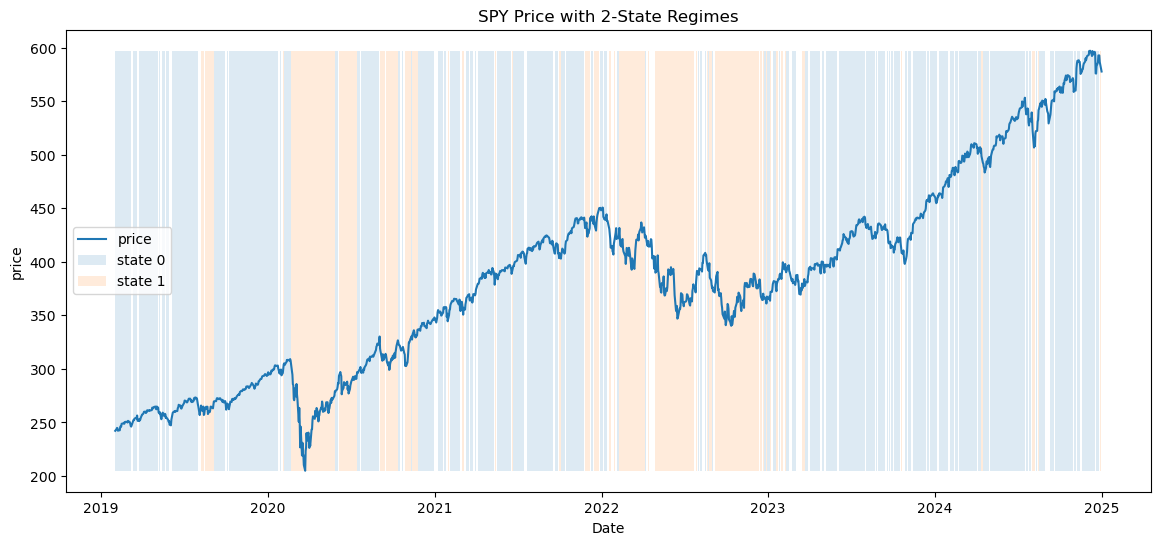

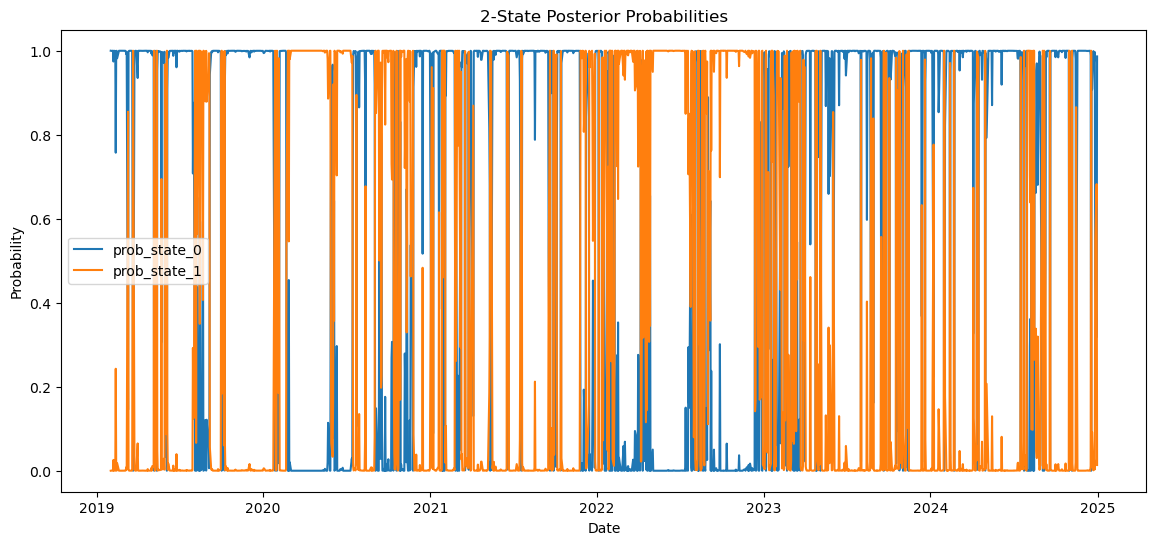

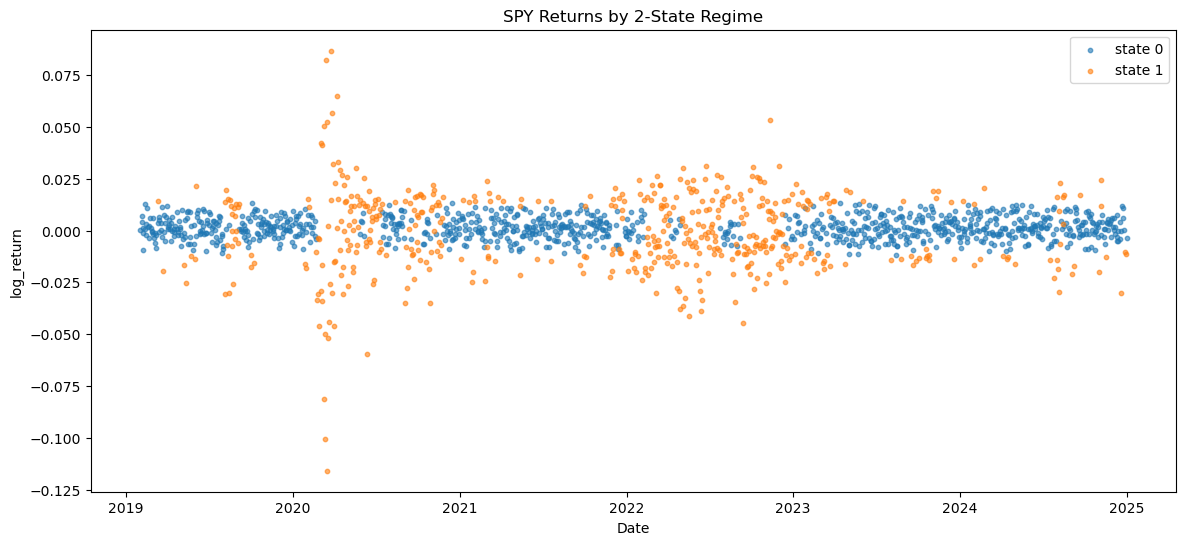

In [61]:
plot_price_with_regimes(result_df_2, price_col="price", title="SPY Price with 2-State Regimes")
plot_state_probabilities(result_df_2, n_states=2, title="2-State Posterior Probabilities")
plot_returns_by_state(result_df_2, return_col="log_return", title="SPY Returns by 2-State Regime")